In [1]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [3]:
import numpy as np
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, array_to_img, load_img

# Define image size
IMG_SIZE = 128  # For simplicity, we resize all images to 128x128

# Set up the image data generator with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Example function to load and preprocess images from a folder
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Example for applying data augmentation to images



In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define a simple CNN model
def create_cnn_model():
    model = models.Sequential()

    # Convolutional layers with ReLU activation and max-pooling
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten the output and add a fully connected layer
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))

    # Output layer with softmax activation (for multiclass classification)
    model.add(layers.Dense(2, activation='softmax'))  # Assuming 4 classes: Healthy, Dental Caries, Gingivitis, etc.

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Create the CNN model
model = create_cnn_model()

# Print model summary to check layers and parameters
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import comet_ml
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, array_to_img, load_img

# ... (Your previous code for model definition and datagen) ...

# Assuming your images are in a directory called 'train_data' and 'val_data'
train_data_dir = '/content/drive/MyDrive/OA/TRAIN'  # Replace with your training data directory
  # Replace with your validation data directory


# Create image generators for training and validation
train_generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,  # Adjust as needed
    class_mode='categorical'  # Use 'binary' for binary classification
)



# Initialize Comet.ml experiment
experiment = comet_ml.Experiment(api_key="M8WTc5pMQMez5DnJlG5DrV5hg", project_name="oral-disease-classification")

# Define early stopping and model checkpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,  # Use the training data generator
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Calculate steps per epoch
    epochs=30, # Use the validation data generator  # Calculate validation steps
    callbacks=[early_stopping, model_checkpoint]
)

# Log the metrics to comet.ml
experiment.log_metric('accuracy', history.history['accuracy'][-1])

experiment.log_metric('loss', history.history['loss'][-1])


Found 1486 images belonging to 2 classes.


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorflow, keras.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : delicate_pastry_1888
COMET INFO:     url                   : https://www.comet.com/bhagyashri-agasar/oral-disease-classification/bcd47a577e734029946c2a1e01857491
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1A4aGojfAiFE54P9wyaQidIDBNRn103WF
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 2
COMET INFO:     os packages         : 1
COMET INFO:     so

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5886 - loss: 0.7208
Epoch 2/30


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.7500 - loss: 0.4253 
Epoch 3/30


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7413 - loss: 0.5068
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 256us/step - accuracy: 0.7188 - loss: 0.5069 
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7968 - loss: 0.4442
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step - accuracy: 0.7500 - loss: 0.4210
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7901 - loss: 0.4351
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step - accuracy: 0.8750 - loss: 0.2667 
Epoch 9/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8260 - loss: 0.3735
Epoch 10/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 228us/step - accuracy: 0.7500 - loss: 0.4312 
Epoch 11/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8487 - loss: 0.3253
Epoch 12/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 223us/step - accuracy: 0.8438 - loss: 0.3953 
Epoch 13/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8538 - loss: 0.3408
Epoch 14/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 370us/step - accuracy: 0.81

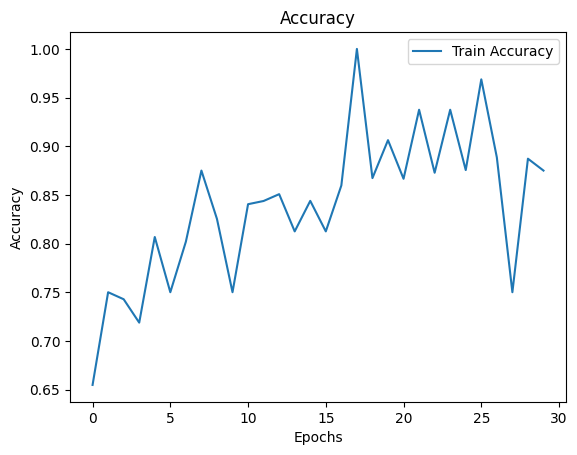

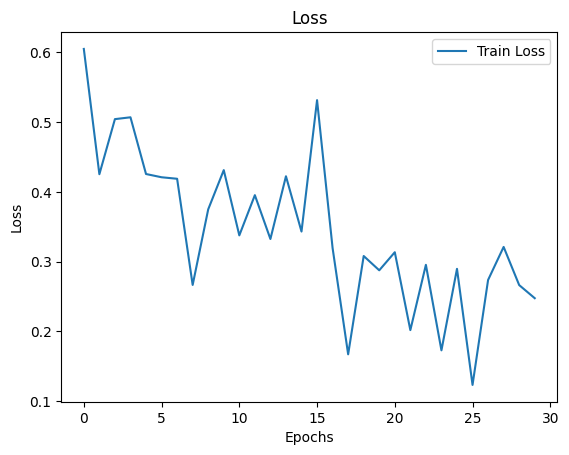

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss
def plot_metrics(history):
    # Accuracy
    plt.plot(history.history['accuracy'], label='Train Accuracy')

    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss
    plt.plot(history.history['loss'], label='Train Loss')

    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Visualize the training results
plot_metrics(history)


In [37]:
model.save('/content/drive/MyDrive/Colab Notebooks/oral_disease_model.h5')

In [42]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define the image size expected by the model
IMG_SIZE = 128  # Update based on your model's expected input size

# Define the class names (make sure they match the order of the classes in your model)
class_names = ["Caries", "Gingivitis"]

# Preprocess a single image for prediction
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))  # Resize image to match model input
    img_array = img_to_array(img)  # Convert to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values
    return img_array

# Load the trained model
model = tf.keras.models.load_model('oral_disease_model.h5')

# Compile the model if needed (use the same optimizer, loss, and metrics as during training)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [43]:
# Load test data from a folder
def load_test_data(test_folder_path):
    images = []
    labels = []

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(test_folder_path, class_name)

        for image_name in os.listdir(class_folder):
            if image_name.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(class_folder, image_name)
                img_array = preprocess_image(image_path)
                images.append(img_array)
                labels.append(class_idx)  # The label is the index of the class

    # Convert lists to numpy arrays
    images = np.vstack(images)  # Stack all images into a single array
    labels = np.array(labels)   # Convert labels to numpy array
    return images, labels

# Example path to your test data folder
test_folder_path = '/content/drive/MyDrive/OA/TEST'

# Load the test images and labels
X_test, y_test = load_test_data(test_folder_path)


In [47]:


import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical  # Import to_categorical

# ... (your existing code) ...

# Load test data from a folder
def load_test_data(test_folder_path):
    images = []
    labels = []

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(test_folder_path, class_name)

        for image_name in os.listdir(class_folder):
            if image_name.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(class_folder, image_name)
                img_array = preprocess_image(image_path)
                images.append(img_array)
                labels.append(class_idx)  # The label is the index of the class

    # Convert lists to numpy arrays
    images = np.vstack(images)  # Stack all images into a single array
    labels = np.array(labels)   # Convert labels to numpy array

    # One-hot encode the labels
    labels = to_categorical(labels, num_classes=len(class_names))

    return images, labels
    # Evaluate the model on the test set
test_folder_path = '/content/drive/MyDrive/OA/TEST'

model = tf.keras.models.load_model('oral_disease_model.h5')
# Load the test images and labels
X_test, y_test = load_test_data(test_folder_path)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, batch_size=32)  # You can adjust the batch_size

# Print the evaluation results
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.8789 - loss: 0.2956
Test Loss: 0.2051
Test Accuracy: 91.67%


In [49]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Define class names (use your model's class names here)
class_names = ["Caries", "Gingivitis"]

# Load your trained model
model = tf.keras.models.load_model('oral_disease_model.h5')

# Compile the model if necessary
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Preprocess the images and labels for evaluation
def preprocess_image(image_path, img_size=128):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(img_size, img_size))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize to [0, 1]
    return img_array

# Load the test data
def load_test_data(test_folder_path):
    images = []
    labels = []

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(test_folder_path, class_name)
        for image_name in os.listdir(class_folder):
            if image_name.endswith(('.jpg', '.png', '.jpeg')):
                image_path = os.path.join(class_folder, image_name)
                img_array = preprocess_image(image_path)
                images.append(img_array)
                labels.append(class_idx)  # The label is the index of the class

    images = np.vstack(images)  # Stack all images into a single array
    labels = np.array(labels)   # Convert labels to numpy array
    return images, labels

# Load the test data from the folder
test_folder_path = '/content/drive/MyDrive/OA/TEST'  # Update with actual path
X_test, y_test = load_test_data(test_folder_path)

# Get model predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Generate the classification report (includes accuracy, precision, recall, F1-Score)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# Print the classification report
print("Classification Report:\n", report)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]



13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 588ms/step
Classification Report:
 {'Caries': {'precision': 0.9521276595744681, 'recall': 0.8774509803921569, 'f1-score': 0.9132653061224489, 'support': 204.0}, 'Gingivitis': {'precision': 0.8863636363636364, 'recall': 0.9558823529411765, 'f1-score': 0.9198113207547169, 'support': 204.0}, 'accuracy': 0.9166666666666666, 'macro avg': {'precision': 0.9192456479690523, 'recall': 0.9166666666666667, 'f1-score': 0.9165383134385829, 'support': 408.0}, 'weighted avg': {'precision': 0.9192456479690523, 'recall': 0.9166666666666666, 'f1-score': 0.9165383134385829, 'support': 408.0}}


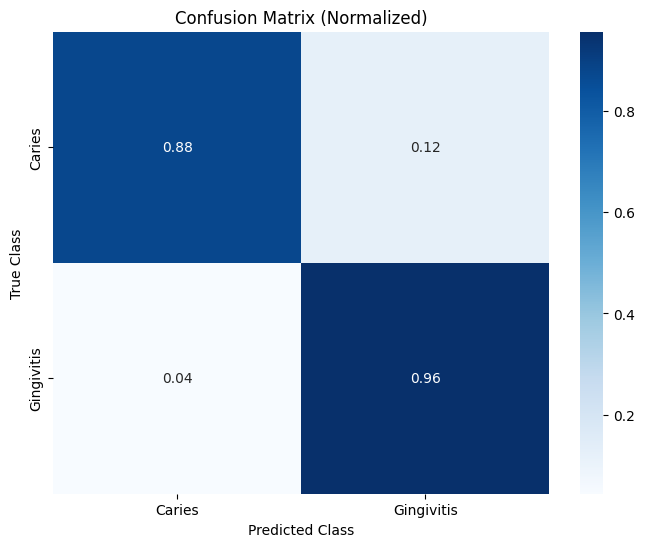

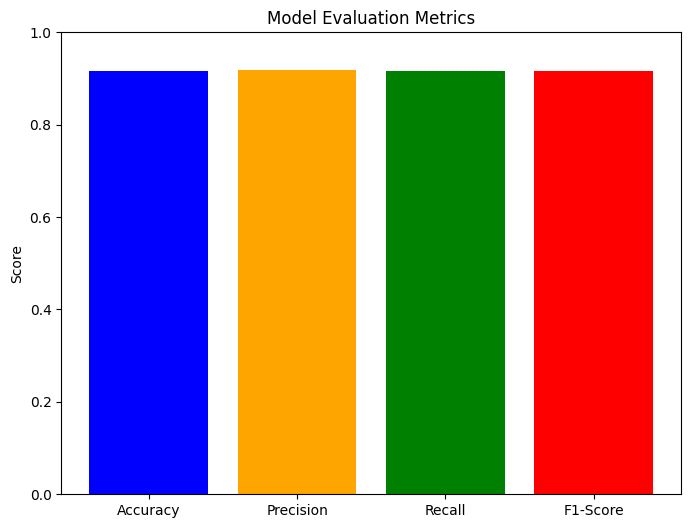

In [55]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# Plot Classification Report (Precision, Recall, F1-Score)
# Extract metrics from the classification report
accuracy = report['accuracy']
precision = np.mean([report[class_name]['precision'] for class_name in class_names])
recall = np.mean([report[class_name]['recall'] for class_name in class_names])
f1_score = np.mean([report[class_name]['f1-score'] for class_name in class_names])

# Create a bar chart to visualize precision, recall, and F1-score
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1_score]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()
